In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Dataset,Subset,DataLoader,random_split
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
import itertools

In [2]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Architecture

In [3]:
class Discriminator(nn.Module):
  def __init__(self,in_features):
    super().__init__()
    self.disc = nn.Sequential(
        nn.Linear(in_features,128),
        nn.LeakyReLU(0.1),
        nn.Linear(128,1),
        nn.Sigmoid()
    )

  def forward(self,x):
    return self.disc(x)

In [4]:
class Generator(nn.Module):
  def __init__(self,z_dim,img_dim):
    super().__init__()
    self.gen = nn.Sequential(
        nn.Linear(z_dim,256),
        nn.LeakyReLU(0.1),
        nn.Linear(256,img_dim),
        nn.Tanh()
    )

  def forward(self,x):
    return self.gen(x)

In [5]:
'''
class GAN(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.cfg=cfg
    self.disc = Discriminator(cfg.img_dim)
    self.gen = Generator(cfg.z_dim,cfg.img_dim)

  def generate(self):
    z=torch.randn(self.cfg.batch_size,self.cfg.z_dim).to(device)
    return self.gen(z)

  def forward(self,x):
    return self.disc(x)*(1-self.disc(self.generate()))
    '''

  # 이렇게 하는것 보단 따로따로 하는게 더 편할 듯


'\nclass GAN(nn.Module):\n  def __init__(self,cfg):\n    super().__init__()\n    self.cfg=cfg\n    self.disc = Discriminator(cfg.img_dim)\n    self.gen = Generator(cfg.z_dim,cfg.img_dim)\n\n  def generate(self):\n    z=torch.randn(self.cfg.batch_size,self.cfg.z_dim).to(device)\n    return self.gen(z)\n\n  def forward(self,x):\n    return self.disc(x)*(1-self.disc(self.generate()))\n    '

# HyperParameter and Config

In [6]:
class GANConfig:
  z_dim: int = 64
  img_dim: int = 28*28*1

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
lr=3e-4
batch_size=32
epochs = 50

In [8]:
disc_loss_list=[]
gen_loss_list=[]

#best_disc_loss=float('inf')
best_gen_loss=float('inf')

start_epoch=0

# Dataset

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])

In [10]:
dataset=datasets.MNIST(
    root='dataset/',
    train=True,
    transform=transform,
    download=True
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.45MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.83MB/s]


In [11]:
loader=DataLoader(dataset,batch_size=batch_size,shuffle=True)

# Model

In [12]:
disc=Discriminator(GANConfig.img_dim).to(device)
gen=Generator(GANConfig.z_dim,GANConfig.img_dim).to(device)

In [13]:
fixed_noise=torch.randn((batch_size,GANConfig.z_dim)).to(device)

In [14]:
opt_disc=optim.Adam(disc.parameters(),lr=lr)
opt_gen=optim.Adam(gen.parameters(),lr=lr)
criterion=nn.BCELoss()

# Load

In [15]:
path=f'/content/drive/MyDrive/DeepLerning (military)/Deep-Learning-Study/GAN'

In [24]:
def load_model(
    path,
    disc, gen,
    opt_disc, opt_gen,
    disc_loss_list, gen_loss_list,
    device
):

  if not os.path.exists(path):
    print("체크포인트 없음, 처음부터 시작")
    return [],[],0

  checkpoint = torch.load(path, map_location=device)
  disc.load_state_dict(checkpoint['disc_state_dict'])
  gen.load_state_dict(checkpoint['gen_state_dict'])
  opt_disc.load_state_dict(checkpoint['opt_disc_state_dict'])
  opt_gen.load_state_dict(checkpoint['opt_gen_state_dict'])
  disc_loss_list = checkpoint['disc_loss_list']
  gen_loss_list = checkpoint['gen_loss_list']
  start_epoch = checkpoint['epoch'] + 1
  print("체크포인트 로드 완료")

  return disc_loss_list, gen_loss_list, start_epoch

# Training

In [17]:
from torch.utils.tensorboard import SummaryWriter

writerfake=SummaryWriter(f'{path}/logs/fake')
writerreal=SummaryWriter(f'{path}/logs/real')

In [18]:
lossD_sum=0.0
lossG_sum=0.0
iter_sum=0

In [25]:
disc_loss_list,gen_loss_list,start_epoch=load_model(
    f'{path}/GAN1.pth',
    disc, gen,
    opt_disc, opt_gen,
    disc_loss_list, gen_loss_list,
    device
)

체크포인트 로드 완료


In [29]:
print(os.path.exists(path))
print(os.path.exists(f'{path}/logs/fake'))
print(os.listdir(f'{path}/logs/fake'))

True
True
['events.out.tfevents.1789894136.9d2ccb94b58d.820.0']


In [27]:
for epoch in tqdm(range(start_epoch,epochs),initial=start_epoch,total=epochs, desc="Epoch"):
  for batch_idx, (real,_) in tqdm(enumerate(loader), desc="Iteration", total=len(loader), leave=False):
    real=real.view(-1,28*28).to(device)
    batch_size=real.shape[0]

    noise=torch.randn(batch_size,GANConfig.z_dim).to(device)
    fake=gen(noise)

    disc_real=disc(real).view(-1)
    disc_fake=disc(fake.detach()).view(-1)

    lossD_real=criterion(disc_real,torch.ones_like(disc_real))
    lossD_fake=criterion(disc_fake,torch.zeros_like(disc_real))
    lossD=(lossD_real+lossD_fake)/2
    lossD_sum+=lossD.item()
    opt_disc.zero_grad()
    lossD.backward()
    opt_disc.step()

    output=disc(fake).view(-1)
    lossG=criterion(output,torch.ones_like(output))
    lossG_sum+=lossG.item()
    opt_gen.zero_grad()
    lossG.backward()
    opt_gen.step()

    iter_sum+=1

  disc_loss_list.append(lossD_sum/iter_sum)
  gen_loss_list.append(lossG_sum/iter_sum)
  lossD_sum=0.0
  lossG_sum=0.0
  iter_sum=0

  print(
      f"Epoch [{epoch+1}/{epochs}]"
      f"Loss D: {disc_loss_list[-1]:.4f}"
      f"Loss G: {gen_loss_list[-1]:.4f}"
  )

  with torch.no_grad():
    fake=gen(fixed_noise).reshape(-1,1,28,28)
    data=real.reshape(-1,1,28,28)

    img_grid_fake=torchvision.utils.make_grid(fake,normalize=True)
    img_grid_real=torchvision.utils.make_grid(data,normalize=True)

    writerfake.add_image("Fake",img_grid_fake,global_step=epoch)
    writerreal.add_image("Real",img_grid_real,global_step=epoch)

  torch.save({
      'epoch':epoch,
      'disc_state_dict':disc.state_dict(),
      'gen_state_dict':gen.state_dict(),
      'opt_disc_state_dict':opt_disc.state_dict(),
      'opt_gen_state_dict':opt_gen.state_dict(),
      'disc_loss_list':disc_loss_list,
      'gen_loss_list':gen_loss_list
  },f'{path}/GAN1.pth')

Epoch:   0%|          | 0/50 [00:00<?, ?it/s]

Iteration:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch [1/50]Loss D: 0.2019Loss G: 2.1565


Iteration:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch [2/50]Loss D: 0.0916Loss G: 3.3703


...

Epoch [48/50]Loss D: 0.0040Loss G: 8.6493


Iteration:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch [49/50]Loss D: 0.0041Loss G: 8.7175


Iteration:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch [50/50]Loss D: 0.0036Loss G: 8.6978


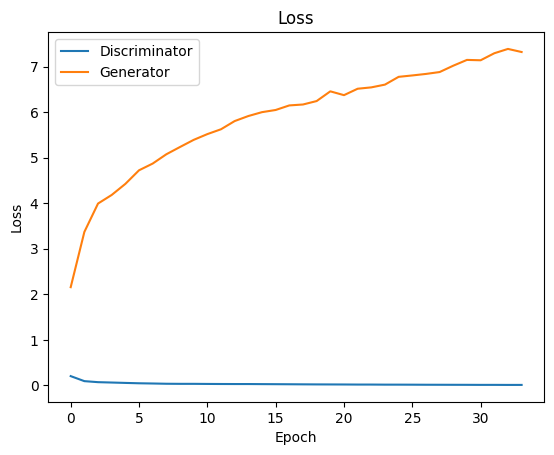

In [28]:
plt.plot(disc_loss_list, label='Discriminator')
plt.plot(gen_loss_list, label='Generator')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 끄지 마세요 제발 ㅠㅠ